# Data Challenge 7 — Evaluating SLR, Assumptions, & the Bias–Variance Tradeoff

**Goal:** Fit a simple linear regression (SLR) with a **train–test split**, report **MAE/RMSE** on *unseen* data, and use **training residuals** to check assumptions. Explain **bias vs. variance** in plain English.


> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple* — minimal coercion for chosen columns only.

## We Do — Instructor Session (20 mins)
Use this **step-by-step plan** to guide students. Keep it high-level; they will implement in the *You Do* section.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- MAE / MSE / RMSE — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- OLS (fit/predict/residuals) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (attributes like `resid`, `fittedvalues`, `summary`) — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- Q–Q plot — SciPy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html

### Pseudocode Plan
1) **Load CSV** → preview columns/shape.
2) **Assign Y and X (one predictor)** → pick numeric columns that matter; if needed, coerce **just** these to numeric and drop NAs.
3) **Add intercept** → `X = add_constant(X)`.
4) **Train–test split (80/20)** → `X_train, X_test, y_train, y_test = train_test_split(...)` (set `random_state`).
5) **Fit on TRAIN** → `model = OLS(y_train, X_train).fit()`.
6) **Predict on TEST** → `y_pred = model.predict(X_test)`.
7) **Evaluate on TEST** → compute **MAE** and **RMSE** using `y_test` & `y_pred`; speak in **units of Y**.
8) **Diagnostics on TRAIN** → use `model.resid` & `model.fittedvalues` for residuals vs fitted; Q–Q plot; check Durbin–Watson in `model.summary()`.
9) **Bias–variance read (optional)** → compare train vs test errors.
10) **Stakeholder one-liner** → MAE/RMSE in units + brief reliability note.


## You Do — Student Section
Work in pairs. Keep code simple and comment your choices.

### Step 0 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Step 1 & 2 — Read in the file and Choose **Y** (target) and **X** (one predictor)
- Keep them numeric and present in your CSV.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [ ]:
# Loading csv to variable
df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")

# Coerce fare, distance to numeric safely
num_cols = ['fare_amount', 'trip_distance']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_19494/1408614365.py:2: DtypeWarning: Columns (4,10,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/2023_Yellow_Taxi_Trip_Data_20251015.csv")


In [6]:
# Clean data some by removing values less than 0 and dropping NAN values
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)

# picking values that are less than the 99.99% because there are some significantly high values
df = df[df['fare_amount'] <= df['fare_amount'].quantile(0.9999)]
df = df[df['trip_distance'] <= df['trip_distance'].quantile(0.9999)]

### Step 3 — Train–Test Split (80/20 random split for practice)

In [ ]:
np.random.seed(42)

X = sm.add_constant(df['trip_distance'])
y = df['fare_amount']


# 80 20 split for training / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X Training data shape: {X_train.shape}")
print(f"X Testing data shape:  {X_test.shape}")
print(f"Y Training data shape: {y_train.shape}")
print(f"Y Testing data shape:  {y_test.shape}")


X Training data shape: (2559692, 2)
X Testing data shape:  (639923, 2)
Y Training data shape: (2559692,)
Y Testing data shape:  (639923,)


### Step 4 — Fit on TRAIN only; Evaluate on TEST
Compute **MAE** and **RMSE** in the **units of Y**.

In [21]:
# training model
model = sm.OLS(y_train, X_train).fit()

# --- Evaluate the model on the unseen testing data ---
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"\nMean Absolute Error (MAE) on Test Data: {mae:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse:.2f}")
print(f"\nInterpretation: Our model's predictions on new data are off by an average of ${mae*1000:,.2f}.")

y_test.describe()


Mean Absolute Error (MAE) on Test Data: 3.77
Root Mean Squared Error (RMSE) on Test Data: 6.42

Interpretation: Our model's predictions on new data are off by an average of $3,768.48.


count    639923.000000
mean         19.942588
std          17.209672
min           0.010000
25%           9.300000
50%          14.200000
75%          23.300000
max         279.500000
Name: fare_amount, dtype: float64

### Step 5 — Diagnostic Plots (TRAIN residuals)
Check regression assumptions using **training** residuals.
- **Homoscedasticity:** random cloud around 0 (no cone).
- **Normality:** Q–Q plot ~ diagonal.

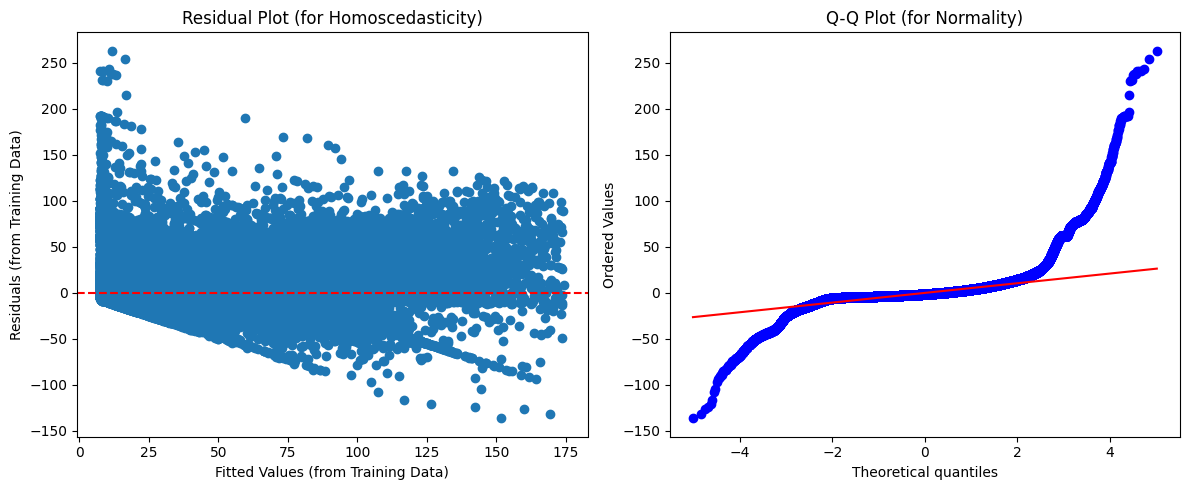

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                 1.579e+07
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        11:50:13   Log-Likelihood:            -8.4005e+06
No. Observations:             2559692   AIC:                         1.680e+07
Df Residuals:                 2559690   BIC:                         1.680e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.6097      0.005   1496.872

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- Check assumptions using the training data model ---
# Residuals from the model trained on X_train, y_train
train_residuals = model.resid 

# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(model.fittedvalues, train_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(train_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()

# 3. Durbin-Watson statistic is in the summary output below
print(model.summary())

### Step 6 — Quick Bias–Variance Read (optional)
Compare **train** and **test** errors and describe what you see.

In [20]:
# Comparing Y Test and Y Train

print('Y (Test)')
display(y_test)
print('\nY (Train)')
display(y_train)

# values are relatively close to each other in test and train

Y (Test)


1780110     6.5
101999     31.7
3091591    10.7
937427     10.7
502770     33.1
           ... 
484101     30.3
958752     70.0
2901559     7.9
3113943    24.0
1634295    70.0
Name: fare_amount, Length: 639923, dtype: float64


Y (Train)


3068274     9.3
1824411    27.5
2283957    12.1
2008690    28.2
698567     13.5
           ... 
1746086    18.4
2435058    12.8
2303741    70.0
2863570    48.5
2293131     6.5
Name: fare_amount, Length: 2559692, dtype: float64

## We Share — Reflection & Wrap‑Up
Write **1–2 short paragraphs** addressing:


1) **Is this model good enough** for a real decision **right now**? Why/why not?
Refer to **MAE/RMSE in units**, any **assumption issues**, and whether accuracy meets a reasonable business threshold.

I wouldn't say the model is good enough for decisions currently as it is not taking into account other variables that would impact our Y (fare_amount). For a general estimate of the impact trip distance has on fare amount it could serve as useful, as our RAE is at $3.77, which when translated to a real world scenario is not very far off from our line of best fit.

2) **What’s your next move** to improve trust/accuracy?
Examples: adopt a **time‑aware split**, try a more relevant **X**, transform variables, segment checks (hour/zone), or move to **Multiple Linear Regression** with validation.

The next step should be moving to multiple linear regressions, as we determined a R squared for fare amount and trip distance to be 86%. This would mean the two values are significantly correlated, also shown with the OLS Regression result's P-Value of less than 0.00%. Knowing all of this information, I would say our next step would be to figure out what else attributes to fare amount's value and predict future fare amounts.